**TUGAS BESAR VINCEN**

In [ ]:
# Install dependencies
# !pip install pandas scikit-learn matplotlib seaborn

#Unsupervised learning (Kmeans)

In [4]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tabulate import tabulate

In [5]:
# Tahap 1: Memuat data
# Membaca file CSV ke dalam DataFrame
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Melihat sekilas data
print("Sekilas data:")
print(data.head())

Sekilas data:
       Date Location ISO Code     Location  New Cases  New Deaths  \
0  3/1/2020             ID-JK  DKI Jakarta          3           0   
1  3/1/2020             ID-JB   Jawa Barat          3           0   
2  3/2/2020             ID-JK  DKI Jakarta          2           0   
3  3/2/2020             ID-JB   Jawa Barat          0           0   
4  3/2/2020               IDN    Indonesia          2           0   

   New Recovered  New Active Cases  Total Cases  Total Deaths  \
0              0                 3            3             0   
1              0                 3            3             0   
2              0                 2            5             0   
3              0                 0            3             0   
4              0                 2            2             0   

   Total Recovered  ...   Longitude  Latitude  New Cases per Million  \
0                0  ...  106.836118 -6.204699                   0.28   
1                0  ...  107.603708 

In [6]:
# Tahap 2: Pemrosesan Data
# Memilih kolom yang relevan untuk clustering
selected_columns = ['New Cases', 'New Deaths', 'New Recovered', 'Total Cases', 'Total Deaths', 'Total Recovered']
data_selected = data[selected_columns]

# Menangani data yang hilang (missing values) dengan mengganti nilai NaN menjadi 0
data_selected.fillna(0, inplace=True)

# Standarisasi data agar memiliki distribusi yang seimbang
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)


<ipython-input-6-a113e8b118d4>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected.fillna(0, inplace=True)


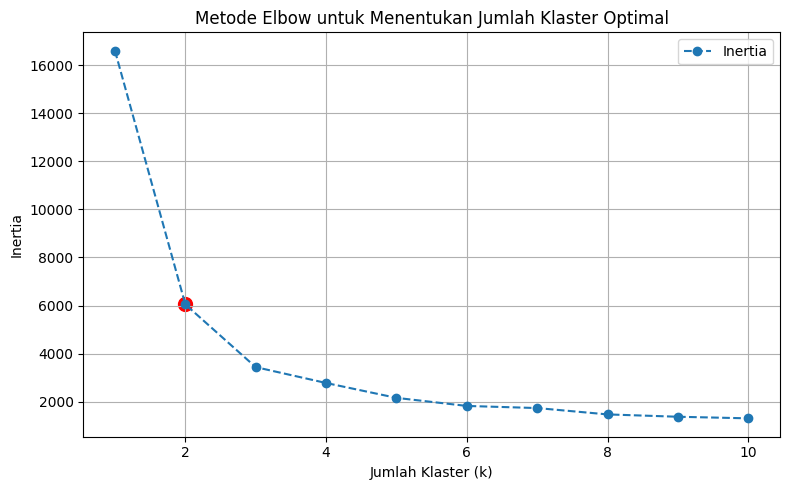

Jumlah klaster optimal berdasarkan Elbow Method: k=2


In [12]:
# Tahap 3: Menentukan jumlah klaster optimal menggunakan Metode Elbow
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Memilih nilai k berdasarkan plot Elbow
def find_optimal_k(inertia, k_values):
    optimal_k = 0
    for i in range(1, len(inertia) - 1):
        if inertia[i - 1] - inertia[i] > inertia[i] - inertia[i + 1]:
            optimal_k = k_values[i]
            break
    return optimal_k

k_optimal = find_optimal_k(inertia, k_values)

# Plot untuk menentukan jumlah klaster optimal
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', label='Inertia')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.grid()
plt.legend()

# Menandai k optimal dengan lingkaran merah
if k_optimal > 0:
    plt.scatter(k_optimal, inertia[k_optimal - 1], color='red', s=100, label=f'Optimal k={k_optimal}')

plt.tight_layout()
plt.savefig('elbow_method_with_optimal_k.png')
plt.show()

print(f"Jumlah klaster optimal berdasarkan Elbow Method: k={k_optimal}")

In [8]:
# Tahap 4: Membuat model KMeans dengan jumlah klaster optimal
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(data_scaled)

# Menambahkan hasil klaster ke dalam DataFrame asli
data['Cluster'] = kmeans.labels_

Silhouette Score untuk k=2: 0.9391602287612603

Hasil Evaluasi:
+------------------+---------+
| Metrik           |   Nilai |
+==================+=========+
| Jumlah Klaster   | 2       |
+------------------+---------+
| Silhouette Score | 0.93916 |
+------------------+---------+


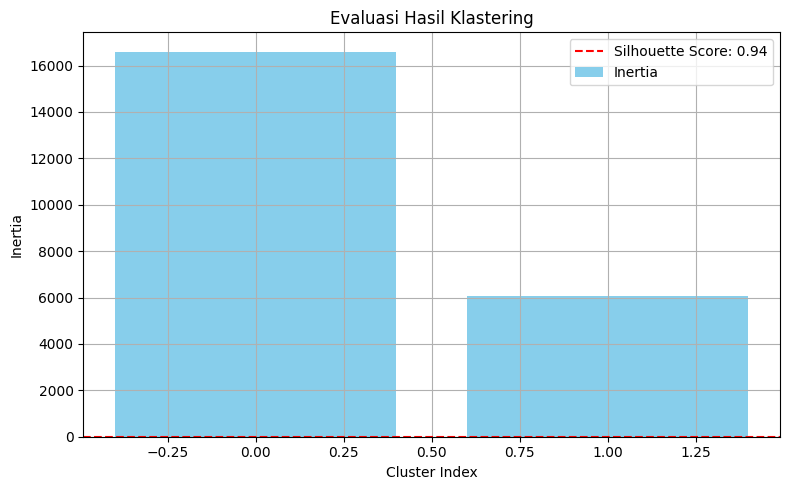

In [9]:
# Tahap 5: Evaluasi Model
# Menggunakan Silhouette Score untuk mengukur kualitas klaster
silhouette_avg = silhouette_score(data_scaled, kmeans.labels_)
print(f"Silhouette Score untuk k={k_optimal}: {silhouette_avg}")

# Menyimpan hasil evaluasi dalam bentuk tabel
evaluation_results = [["Jumlah Klaster", k_optimal], ["Silhouette Score", silhouette_avg]]
evaluation_table = tabulate(evaluation_results, headers=["Metrik", "Nilai"], tablefmt="grid")
print("\nHasil Evaluasi:")
print(evaluation_table)

# Plot evaluasi hasil klaster
plt.figure(figsize=(8, 5))
plt.bar(range(k_optimal), inertia[:k_optimal], color='skyblue', label='Inertia')
plt.axhline(y=silhouette_avg, color='r', linestyle='--', label=f'Silhouette Score: {silhouette_avg:.2f}')
plt.title('Evaluasi Hasil Klastering')
plt.xlabel('Cluster Index')
plt.ylabel('Inertia')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('evaluation_plot.png')
plt.show()

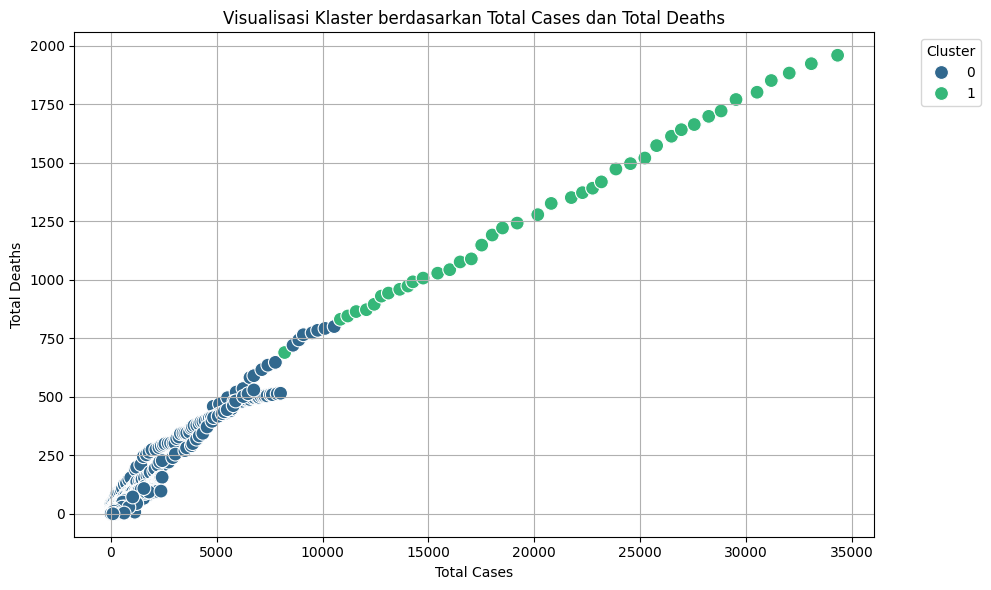

Data hasil clustering telah disimpan ke hasil_clustering_covid19.csv


In [10]:
# Tahap 6: Visualisasi Hasil
# Plot distribusi klaster berdasarkan Total Cases dan Total Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['Total Cases'],
    y=data['Total Deaths'],
    hue=data['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Visualisasi Klaster berdasarkan Total Cases dan Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('cluster_visualization.png')
plt.show()

# Menyimpan data hasil klaster ke file CSV
output_path = 'hasil_clustering_covid19.csv'
data.to_csv(output_path, index=False)
print(f"Data hasil clustering telah disimpan ke {output_path}")

In [11]:
# Tahap 7: Interpretasi Hasil
# Melihat jumlah data pada setiap klaster
cluster_counts = data['Cluster'].value_counts()
print("\nJumlah data pada setiap klaster:")
print(cluster_counts)

# Melihat statistik deskriptif dari setiap klaster
cluster_summary = data.groupby('Cluster')[selected_columns].mean()
print("\nRangkuman statistik untuk setiap klaster:")
print(tabulate(cluster_summary, headers='keys', tablefmt='grid'))

# Menyimpan rangkuman statistik ke file CSV
summary_path = 'cluster_summary_covid19.csv'
cluster_summary.to_csv(summary_path)
print(f"Rangkuman statistik untuk setiap klaster telah disimpan ke {summary_path}")


Jumlah data pada setiap klaster:
Cluster
0    2726
1      41
Name: count, dtype: int64

Rangkuman statistik untuk setiap klaster:
+-----------+-------------+--------------+-----------------+---------------+----------------+-------------------+
|   Cluster |   New Cases |   New Deaths |   New Recovered |   Total Cases |   Total Deaths |   Total Recovered |
+===========+=============+==============+=================+===============+================+===================+
|         0 |      16.015 |     0.980558 |         4.97359 |       416.608 |        30.4219 |           93.8129 |
+-----------+-------------+--------------+-----------------+---------------+----------------+-------------------+
|         1 |     590.293 |    29.2927   |       258.049   |     20634.7   |      1306.29   |         5402.22   |
+-----------+-------------+--------------+-----------------+---------------+----------------+-------------------+
Rangkuman statistik untuk setiap klaster telah disimpan ke cluster_summ

# Unsupervised learning (DBSCAN)

🔍 Sekilas data:
       Date Location ISO Code     Location  New Cases  New Deaths  \
0  3/1/2020             ID-JK  DKI Jakarta          3           0   
1  3/1/2020             ID-JB   Jawa Barat          3           0   
2  3/2/2020             ID-JK  DKI Jakarta          2           0   
3  3/2/2020             ID-JB   Jawa Barat          0           0   
4  3/2/2020               IDN    Indonesia          2           0   

   New Recovered  New Active Cases  Total Cases  Total Deaths  \
0              0                 3            3             0   
1              0                 3            3             0   
2              0                 2            5             0   
3              0                 0            3             0   
4              0                 2            2             0   

   Total Recovered  ...   Longitude  Latitude  New Cases per Million  \
0                0  ...  106.836118 -6.204699                   0.28   
1                0  ...  107.60370

<ipython-input-15-8cbc340f807d>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected.fillna(0, inplace=True)


✔️ Silhouette Score untuk DBSCAN (eps=0.5, min_samples=5): 0.78

📊 Hasil Evaluasi:
+------------------+----------+
| Metrik           |    Nilai |
+==================+==========+
| Jumlah Klaster   | 2        |
+------------------+----------+
| Silhouette Score | 0.784188 |
+------------------+----------+


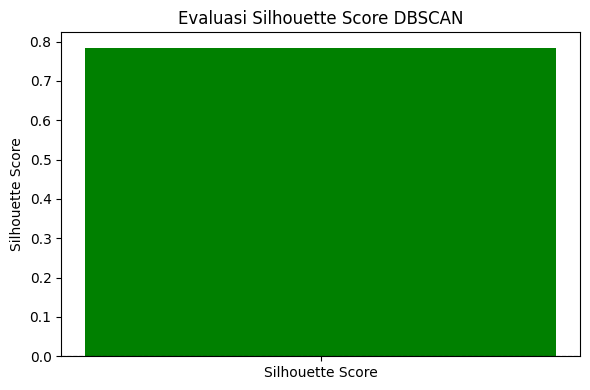

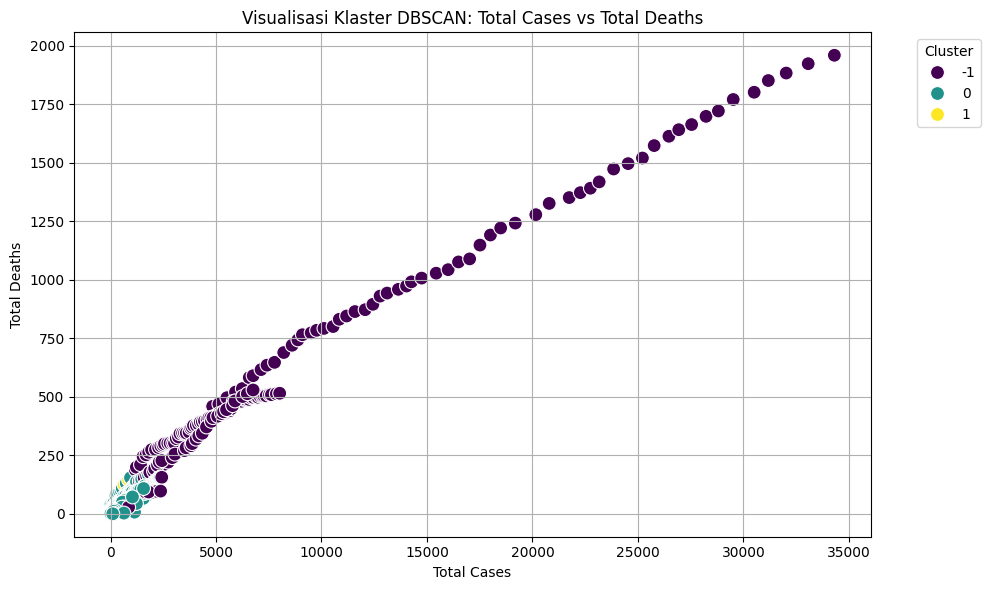

✅ Data hasil clustering telah disimpan ke hasil_clustering_covid19_dbscan.csv

📈 Jumlah data pada setiap klaster:
Cluster
 0    2566
-1     195
 1       6
Name: count, dtype: int64

📊 Rangkuman statistik untuk setiap klaster:
+-----------+-------------+--------------+-----------------+---------------+----------------+-------------------+
|   Cluster |   New Cases |   New Deaths |   New Recovered |   Total Cases |   Total Deaths |   Total Recovered |
+===========+=============+==============+=================+===============+================+===================+
|        -1 |   240.841   |    14.3436   |        92.6974  |      7519.18  |       538.759  |         1754.45   |
+-----------+-------------+--------------+-----------------+---------------+----------------+-------------------+
|         0 |     7.88504 |     0.387373 |         2.34801 |       198.051 |        11.9404 |           52.4883 |
+-----------+-------------+--------------+-----------------+---------------+--------------

<ipython-input-15-8cbc340f807d>:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['Cluster'], palette='coolwarm')


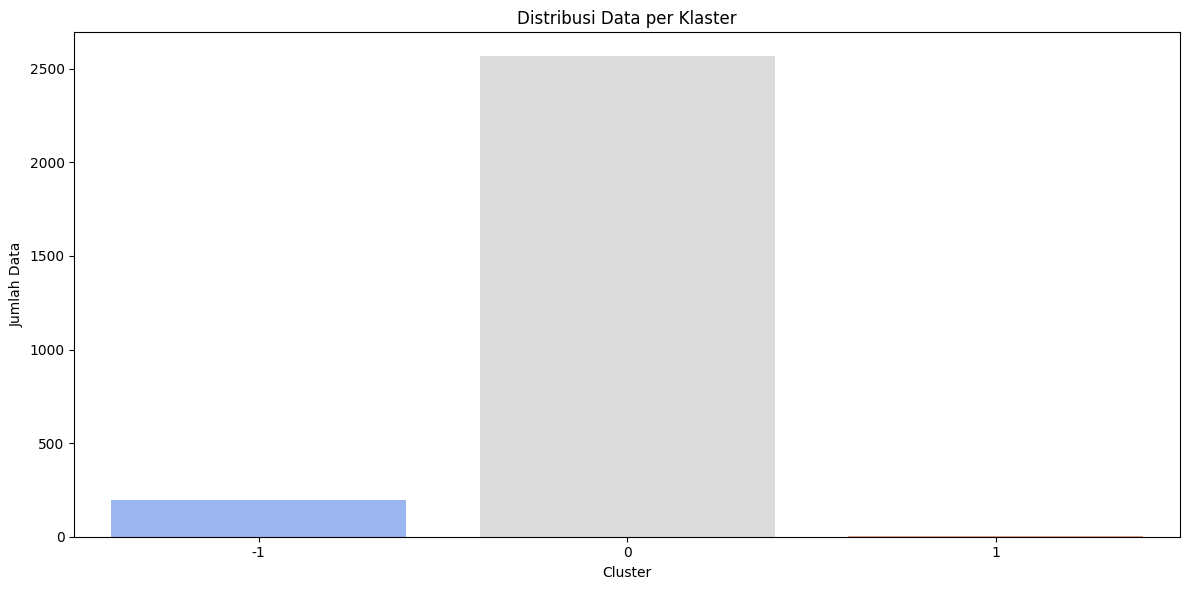

✅ Rangkuman statistik untuk setiap klaster telah disimpan ke cluster_summary_covid19_dbscan.csv


In [15]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from tabulate import tabulate

In [ ]:
# Tahap 1: Memuat Data
# Membaca file CSV ke dalam DataFrame
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Melihat sekilas data
print("🔍 Sekilas data:")
print(data.head())

In [ ]:
# Tahap 2: Pemrosesan Data
# Memilih kolom yang relevan untuk clustering
selected_columns = ['New Cases', 'New Deaths', 'New Recovered', 'Total Cases', 'Total Deaths', 'Total Recovered']
data_selected = data[selected_columns]

# Menangani data yang hilang dengan mengganti nilai NaN menjadi 0
data_selected.fillna(0, inplace=True)

# Standarisasi data untuk keseimbangan distribusi
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

In [ ]:
# Tahap 3: Membuat Model DBSCAN
# Menentukan parameter DBSCAN
eps = 0.5  # Jarak maksimum antara dua sampel untuk dianggap dalam satu klaster
min_samples = 5  # Jumlah minimum sampel dalam klaster

# Membuat model DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(data_scaled)

# Menambahkan hasil klaster ke DataFrame asli
data['Cluster'] = dbscan.labels_


In [ ]:
# Tahap 4: Evaluasi Model
# Menghitung jumlah klaster (mengabaikan noise yang dilabeli -1)
unique_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)

# Menggunakan Silhouette Score jika jumlah klaster lebih dari 1
if unique_clusters > 1:
    silhouette_avg = silhouette_score(data_scaled, dbscan.labels_)
    print(f"✔️ Silhouette Score untuk DBSCAN (eps={eps}, min_samples={min_samples}): {silhouette_avg:.2f}")
else:
    silhouette_avg = "Tidak tersedia (hanya satu klaster atau noise)"
    print("❌ Silhouette Score tidak dapat dihitung karena hanya ada satu klaster atau semua data dianggap noise.")

# Menyimpan hasil evaluasi ke dalam tabel
evaluation_results = [["Jumlah Klaster", unique_clusters], ["Silhouette Score", silhouette_avg]]
evaluation_table = tabulate(evaluation_results, headers=["Metrik", "Nilai"], tablefmt="grid")
print("\n📊 Hasil Evaluasi:")
print(evaluation_table)

# Visualisasi Silhouette Score
plt.figure(figsize=(6, 4))
score_color = 'red' if silhouette_avg == "Tidak tersedia (hanya satu klaster atau noise)" or silhouette_avg < 0 else 'green'
plt.bar(['Silhouette Score'], [0 if silhouette_avg == "Tidak tersedia (hanya satu klaster atau noise)" else silhouette_avg], color=score_color)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Evaluasi Silhouette Score DBSCAN')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('dbscan_silhouette_score.png')
plt.show()

In [ ]:
# Tahap 5: Visualisasi Hasil
# Plot distribusi klaster berdasarkan Total Cases dan Total Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['Total Cases'],
    y=data['Total Deaths'],
    hue=data['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Visualisasi Klaster DBSCAN: Total Cases vs Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('dbscan_cluster_visualization.png')
plt.show()

# Menyimpan data hasil klaster ke file CSV
output_path = 'hasil_clustering_covid19_dbscan.csv'
data.to_csv(output_path, index=False)
print(f"✅ Data hasil clustering telah disimpan ke {output_path}")

In [ ]:
# Tahap 6: Interpretasi Hasil
# Melihat jumlah data pada setiap klaster
cluster_counts = data['Cluster'].value_counts()
print("\n📈 Jumlah data pada setiap klaster:")
print(cluster_counts)

# Rangkuman statistik deskriptif untuk setiap klaster
cluster_summary = data.groupby('Cluster')[selected_columns].mean()
print("\n📊 Rangkuman statistik untuk setiap klaster:")
print(tabulate(cluster_summary, headers='keys', tablefmt='grid'))

# Visualisasi Distribusi Data Per Klaster
plt.figure(figsize=(12, 6))
sns.countplot(x=data['Cluster'], palette='coolwarm')
plt.title('Distribusi Data per Klaster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.savefig('dbscan_cluster_distribution.png')
plt.show()

# Menyimpan rangkuman statistik ke file CSV
summary_path = 'cluster_summary_covid19_dbscan.csv'
cluster_summary.to_csv(summary_path)
print(f"✅ Rangkuman statistik untuk setiap klaster telah disimpan ke {summary_path}")

# Supervised learning (GradientBoostingClassifier)

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
from tabulate import tabulate

In [ ]:
# =======================
# Tahap 1: Memuat Dataset
# =======================
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Menampilkan sekilas data
print("\nSekilas dataset:")
print(tabulate(data.head(), headers="keys", tablefmt="grid"))


In [ ]:
# ==============================
# Tahap 2: Eksplorasi Data Awal
# ==============================
print("\nInformasi Dataset:")
print(data.info())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(tabulate(data.describe(), headers="keys", tablefmt="grid"))

# Cek nilai kosong
missing_values = data.isnull().sum()
print("\nJumlah Nilai Kosong:")
print(missing_values[missing_values > 0])

In [ ]:
# ========================
# Tahap 3: Pemrosesan Data
# ========================
selected_features = [
    'New Cases', 'New Deaths', 'New Recovered', 'Total Cases',
    'Total Deaths', 'Total Recovered', 'Population', 'Population Density'
]
label_column = 'Location Level'
data = data.dropna(subset=selected_features + [label_column])

X = data[selected_features]
y = data[label_column]

# Label encoding untuk target kategorikal
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi data menjadi train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
# =========================
# Tahap 4: Pembangunan Model
# =========================
# Menggunakan Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

In [ ]:
# ==========================
# Tahap 5: Evaluasi Model
# ==========================
y_pred = gb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('confusion_matrix_gb.png')
plt.show()

# Classification report
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [ ]:
# ==========================
# Tahap 6: Visualisasi ROC
# ==========================
y_prob = gb_model.predict_proba(X_test)
n_classes = len(label_encoder.classes_)
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.savefig('roc_curve_gb.png')
plt.show()

In [ ]:
# ============================
# Tahap 7: Analisis Fitur
# ============================
feature_importances = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importances")
plt.tight_layout()
plt.savefig('feature_importances_gb.png')
plt.show()

print("\nPentingnya Fitur:")
print(tabulate(feature_importances, headers="keys", tablefmt="grid"))

In [ ]:
# ============================
# Tahap 8: Output Prediksi
# ============================
sample_predictions = pd.DataFrame({
    'Index': data.index[:10],
    'Actual': label_encoder.inverse_transform(y_test[:10]),
    'Predicted': label_encoder.inverse_transform(y_pred[:10])
})
print("\nPrediksi pada Sampel:")
print(tabulate(sample_predictions, headers="keys", tablefmt="grid"))

# Visualisasi hasil prediksi sampel
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Actual'],
    label='Actual',
    color='blue'
)
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Predicted'],
    label='Predicted',
    color='orange'
)
plt.title("Visualisasi Hasil Prediksi")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Location Level")
plt.tight_layout()
plt.savefig('sample_predictions_gb.png')
plt.show()

In [ ]:
# ============================
# Tahap 9: Menyimpan Model
# ============================
model_path = 'gradient_boosting_model.pkl'
joblib.dump(gb_model, model_path)
print(f"Model disimpan ke: {model_path}")

In [ ]:
# ============================
# Tahap 10: Interpretasi Lanjutan
# ============================
print("\nModel ini telah dievaluasi dengan visualisasi yang tersedia:")
print("- Matriks Kebingungan: confusion_matrix_gb.png")
print("- Kurva ROC: roc_curve_gb.png")
print("- Pentingnya Fitur: feature_importances_gb.png")
print("- Prediksi Sampel: sample_predictions_gb.png")

# Supervised learning (RandomForestClassifier)

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
from tabulate import tabulate

In [ ]:
# =======================
# Tahap 1: Memuat Dataset
# =======================
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Menampilkan sekilas data
print("\nSekilas dataset:")
print(tabulate(data.head(), headers="keys", tablefmt="grid"))

In [ ]:
# ==============================
# Tahap 2: Eksplorasi Data Awal
# ==============================
print("\nInformasi Dataset:")
print(data.info())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(tabulate(data.describe(), headers="keys", tablefmt="grid"))

# Cek nilai kosong
missing_values = data.isnull().sum()
print("\nJumlah Nilai Kosong:")
print(missing_values[missing_values > 0])

In [ ]:
# ========================
# Tahap 3: Pemrosesan Data
# ========================
selected_features = [
    'New Cases', 'New Deaths', 'New Recovered', 'Total Cases',
    'Total Deaths', 'Total Recovered', 'Population', 'Population Density'
]
label_column = 'Location Level'
data = data.dropna(subset=selected_features + [label_column])

X = data[selected_features]
y = data[label_column]

# Label encoding untuk target kategorikal
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi data menjadi train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
# =========================
# Tahap 4: Pembangunan Model
# =========================
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

In [ ]:
# ==========================
# Tahap 5: Evaluasi Model
# ==========================
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Classification report
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [ ]:
# ==========================
# Tahap 6: Visualisasi ROC
# ==========================
y_prob = rf_model.predict_proba(X_test)
n_classes = len(label_encoder.classes_)
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.savefig('roc_curve.png')
plt.show()

In [ ]:
# ============================
# Tahap 7: Analisis Fitur
# ============================
feature_importances = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importances")
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()

print("\nPentingnya Fitur:")
print(tabulate(feature_importances, headers="keys", tablefmt="grid"))

In [ ]:
# ============================
# Tahap 8: Output Prediksi
# ============================
sample_predictions = pd.DataFrame({
    'Index': data.index[:10],
    'Actual': label_encoder.inverse_transform(y_test[:10]),
    'Predicted': label_encoder.inverse_transform(y_pred[:10])
})
print("\nPrediksi pada Sampel:")
print(tabulate(sample_predictions, headers="keys", tablefmt="grid"))

# Visualisasi hasil prediksi sampel
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Actual'],
    label='Actual',
    color='blue'
)
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Predicted'],
    label='Predicted',
    color='orange'
)
plt.title("Visualisasi Hasil Prediksi")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Location Level")
plt.tight_layout()
plt.savefig('sample_predictions.png')
plt.show()

In [ ]:
# ============================
# Tahap 9: Menyimpan Model
# ============================
model_path = 'random_forest_model.pkl'
joblib.dump(rf_model, model_path)
print(f"Model disimpan ke: {model_path}")

In [ ]:
# ============================
# Tahap 10: Interpretasi Lanjutan
# ============================
print("\nModel ini telah dievaluasi dengan visualisasi yang tersedia:")
print("- Matriks Kebingungan: confusion_matrix.png")
print("- Kurva ROC: roc_curve.png")
print("- Pentingnya Fitur: feature_importances.png")
print("- Prediksi Sampel: sample_predictions.png")

# `PEMISAH INI YANG FULL CODE BUAT COPY AJA DI MAKALAH/PROPOSAL LU`

# Unsupervised learning (Kmeans) Full Code

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tabulate import tabulate

# Tahap 1: Memuat data
# Membaca file CSV ke dalam DataFrame
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Melihat sekilas data
print("Sekilas data:")
print(data.head())

# Tahap 2: Pemrosesan Data
# Memilih kolom yang relevan untuk clustering
selected_columns = ['New Cases', 'New Deaths', 'New Recovered', 'Total Cases', 'Total Deaths', 'Total Recovered']
data_selected = data[selected_columns]

# Menangani data yang hilang (missing values) dengan mengganti nilai NaN menjadi 0
data_selected.fillna(0, inplace=True)

# Standarisasi data agar memiliki distribusi yang seimbang
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

# Tahap 3: Menentukan jumlah klaster optimal menggunakan Metode Elbow
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Plot untuk menentukan jumlah klaster optimal
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', label='Inertia')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('elbow_method.png')
plt.show()

# Memilih nilai k berdasarkan plot Elbow
def find_optimal_k(inertia, k_values):
    optimal_k = 0
    for i in range(1, len(inertia)-1):
        if inertia[i-1] - inertia[i] > inertia[i] - inertia[i+1]:
            optimal_k = k_values[i]
            break
    return optimal_k

k_optimal = find_optimal_k(inertia, k_values)
print(f"Jumlah klaster optimal berdasarkan Elbow Method: k={k_optimal}")

# Tahap 4: Membuat model KMeans dengan jumlah klaster optimal
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(data_scaled)

# Menambahkan hasil klaster ke dalam DataFrame asli
data['Cluster'] = kmeans.labels_

# Tahap 5: Evaluasi Model
# Menggunakan Silhouette Score untuk mengukur kualitas klaster
silhouette_avg = silhouette_score(data_scaled, kmeans.labels_)
print(f"Silhouette Score untuk k={k_optimal}: {silhouette_avg}")

# Menyimpan hasil evaluasi dalam bentuk tabel
evaluation_results = [["Jumlah Klaster", k_optimal], ["Silhouette Score", silhouette_avg]]
evaluation_table = tabulate(evaluation_results, headers=["Metrik", "Nilai"], tablefmt="grid")
print("\nHasil Evaluasi:")
print(evaluation_table)

# Plot evaluasi hasil klaster
plt.figure(figsize=(8, 5))
plt.bar(range(k_optimal), inertia[:k_optimal], color='skyblue', label='Inertia')
plt.axhline(y=silhouette_avg, color='r', linestyle='--', label=f'Silhouette Score: {silhouette_avg:.2f}')
plt.title('Evaluasi Hasil Klastering')
plt.xlabel('Cluster Index')
plt.ylabel('Inertia')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('evaluation_plot.png')
plt.show()

# Tahap 6: Visualisasi Hasil
# Plot distribusi klaster berdasarkan Total Cases dan Total Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['Total Cases'],
    y=data['Total Deaths'],
    hue=data['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Visualisasi Klaster berdasarkan Total Cases dan Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('cluster_visualization.png')
plt.show()

# Menyimpan data hasil klaster ke file CSV
output_path = 'hasil_clustering_covid19.csv'
data.to_csv(output_path, index=False)
print(f"Data hasil clustering telah disimpan ke {output_path}")

# Tahap 7: Interpretasi Hasil
# Melihat jumlah data pada setiap klaster
cluster_counts = data['Cluster'].value_counts()
print("\nJumlah data pada setiap klaster:")
print(cluster_counts)

# Melihat statistik deskriptif dari setiap klaster
cluster_summary = data.groupby('Cluster')[selected_columns].mean()
print("\nRangkuman statistik untuk setiap klaster:")
print(tabulate(cluster_summary, headers='keys', tablefmt='grid'))

# Menyimpan rangkuman statistik ke file CSV
summary_path = 'cluster_summary_covid19.csv'
cluster_summary.to_csv(summary_path)
print(f"Rangkuman statistik untuk setiap klaster telah disimpan ke {summary_path}")


# Unsupervised learning (DBSCAN) Fullcode

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from tabulate import tabulate

# Tahap 1: Memuat Data
# Membaca file CSV ke dalam DataFrame
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Melihat sekilas data
print("🔍 Sekilas data:")
print(data.head())

# Tahap 2: Pemrosesan Data
# Memilih kolom yang relevan untuk clustering
selected_columns = ['New Cases', 'New Deaths', 'New Recovered', 'Total Cases', 'Total Deaths', 'Total Recovered']
data_selected = data[selected_columns]

# Menangani data yang hilang dengan mengganti nilai NaN menjadi 0
data_selected.fillna(0, inplace=True)

# Standarisasi data untuk keseimbangan distribusi
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

# Tahap 3: Membuat Model DBSCAN
# Menentukan parameter DBSCAN
eps = 0.5  # Jarak maksimum antara dua sampel untuk dianggap dalam satu klaster
min_samples = 5  # Jumlah minimum sampel dalam klaster

# Membuat model DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(data_scaled)

# Menambahkan hasil klaster ke DataFrame asli
data['Cluster'] = dbscan.labels_

# Tahap 4: Evaluasi Model
# Menghitung jumlah klaster (mengabaikan noise yang dilabeli -1)
unique_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)

# Menggunakan Silhouette Score jika jumlah klaster lebih dari 1
if unique_clusters > 1:
    silhouette_avg = silhouette_score(data_scaled, dbscan.labels_)
    print(f"✔️ Silhouette Score untuk DBSCAN (eps={eps}, min_samples={min_samples}): {silhouette_avg:.2f}")
else:
    silhouette_avg = "Tidak tersedia (hanya satu klaster atau noise)"
    print("❌ Silhouette Score tidak dapat dihitung karena hanya ada satu klaster atau semua data dianggap noise.")

# Menyimpan hasil evaluasi ke dalam tabel
evaluation_results = [["Jumlah Klaster", unique_clusters], ["Silhouette Score", silhouette_avg]]
evaluation_table = tabulate(evaluation_results, headers=["Metrik", "Nilai"], tablefmt="grid")
print("\n📊 Hasil Evaluasi:")
print(evaluation_table)

# Visualisasi Silhouette Score
plt.figure(figsize=(6, 4))
score_color = 'red' if silhouette_avg == "Tidak tersedia (hanya satu klaster atau noise)" or silhouette_avg < 0 else 'green'
plt.bar(['Silhouette Score'], [0 if silhouette_avg == "Tidak tersedia (hanya satu klaster atau noise)" else silhouette_avg], color=score_color)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Evaluasi Silhouette Score DBSCAN')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('dbscan_silhouette_score.png')
plt.show()

# Tahap 5: Visualisasi Hasil
# Plot distribusi klaster berdasarkan Total Cases dan Total Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['Total Cases'],
    y=data['Total Deaths'],
    hue=data['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Visualisasi Klaster DBSCAN: Total Cases vs Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('dbscan_cluster_visualization.png')
plt.show()

# Menyimpan data hasil klaster ke file CSV
output_path = 'hasil_clustering_covid19_dbscan.csv'
data.to_csv(output_path, index=False)
print(f"✅ Data hasil clustering telah disimpan ke {output_path}")

# Tahap 6: Interpretasi Hasil
# Melihat jumlah data pada setiap klaster
cluster_counts = data['Cluster'].value_counts()
print("\n📈 Jumlah data pada setiap klaster:")
print(cluster_counts)

# Rangkuman statistik deskriptif untuk setiap klaster
cluster_summary = data.groupby('Cluster')[selected_columns].mean()
print("\n📊 Rangkuman statistik untuk setiap klaster:")
print(tabulate(cluster_summary, headers='keys', tablefmt='grid'))

# Visualisasi Distribusi Data Per Klaster
plt.figure(figsize=(12, 6))
sns.countplot(x=data['Cluster'], palette='coolwarm')
plt.title('Distribusi Data per Klaster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.savefig('dbscan_cluster_distribution.png')
plt.show()

# Menyimpan rangkuman statistik ke file CSV
summary_path = 'cluster_summary_covid19_dbscan.csv'
cluster_summary.to_csv(summary_path)
print(f"✅ Rangkuman statistik untuk setiap klaster telah disimpan ke {summary_path}")


# Supervised learning (GradientBoostingClassifier) Full code


Sekilas dataset:
+----+----------+---------------------+-------------+-------------+--------------+-----------------+--------------------+---------------+----------------+-------------------+----------------------+------------------+-------------------+-------------+-----------+-------------+----------+-------------+------------------------+-------------------+----------------+-------------------+------------------------+------------------------+--------------+--------------+----------------------+-------------+------------+-------------------------+---------------------------+--------------------------+----------------------------+----------------------+-----------------------+------------------------------+-------------------------------+
|    | Date     | Location ISO Code   | Location    |   New Cases |   New Deaths |   New Recovered |   New Active Cases |   Total Cases |   Total Deaths |   Total Recovered |   Total Active Cases | Location Level   |   City or Regency | Province   

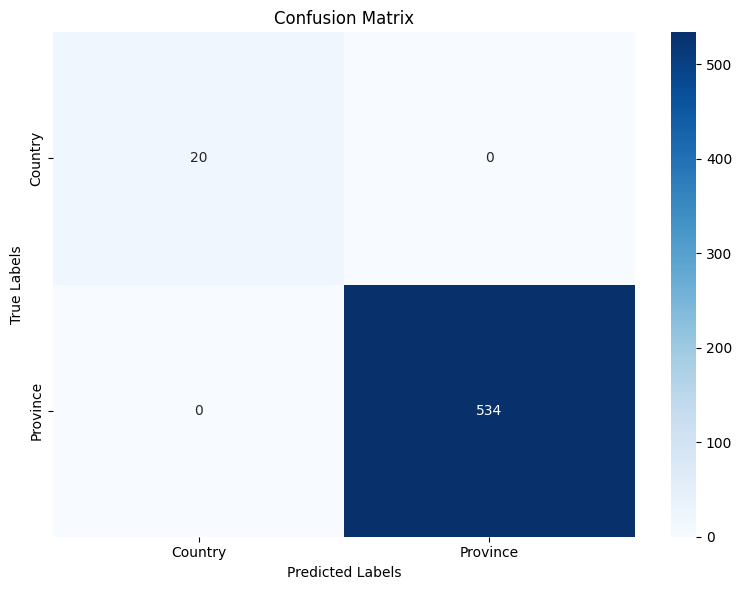


Laporan Klasifikasi:
              precision    recall  f1-score   support

     Country       1.00      1.00      1.00        20
    Province       1.00      1.00      1.00       534

    accuracy                           1.00       554
   macro avg       1.00      1.00      1.00       554
weighted avg       1.00      1.00      1.00       554



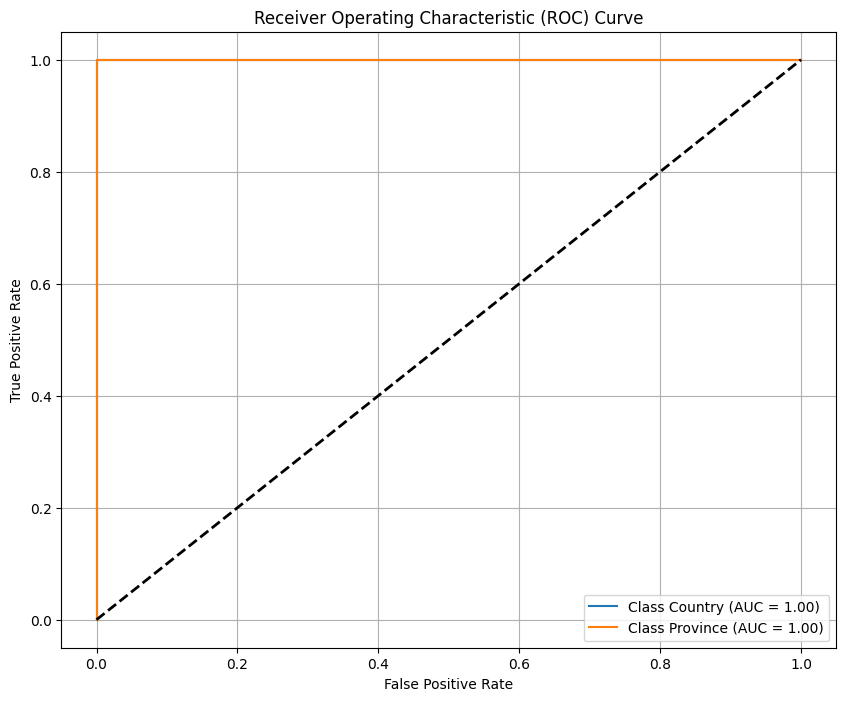

<ipython-input-22-5ffe4ea5a112>:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


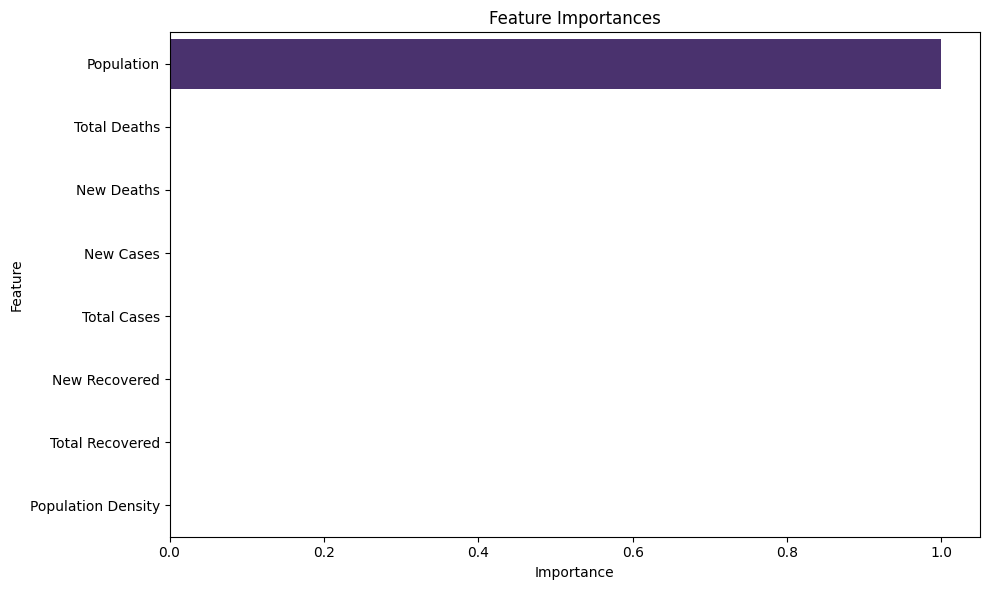


Pentingnya Fitur:
+----+--------------------+--------------+
|    | Feature            |   Importance |
+====+====================+==============+
|  6 | Population         |  1           |
+----+--------------------+--------------+
|  4 | Total Deaths       |  8.88099e-15 |
+----+--------------------+--------------+
|  1 | New Deaths         |  6.68733e-15 |
+----+--------------------+--------------+
|  0 | New Cases          |  3.22295e-15 |
+----+--------------------+--------------+
|  3 | Total Cases        |  1.10464e-15 |
+----+--------------------+--------------+
|  2 | New Recovered      |  8.14129e-16 |
+----+--------------------+--------------+
|  5 | Total Recovered    |  1.72193e-16 |
+----+--------------------+--------------+
|  7 | Population Density |  0           |
+----+--------------------+--------------+

Prediksi pada Sampel:
+----+---------+----------+-------------+
|    |   Index | Actual   | Predicted   |
+====+=========+==========+=============+
|  0 |       0 

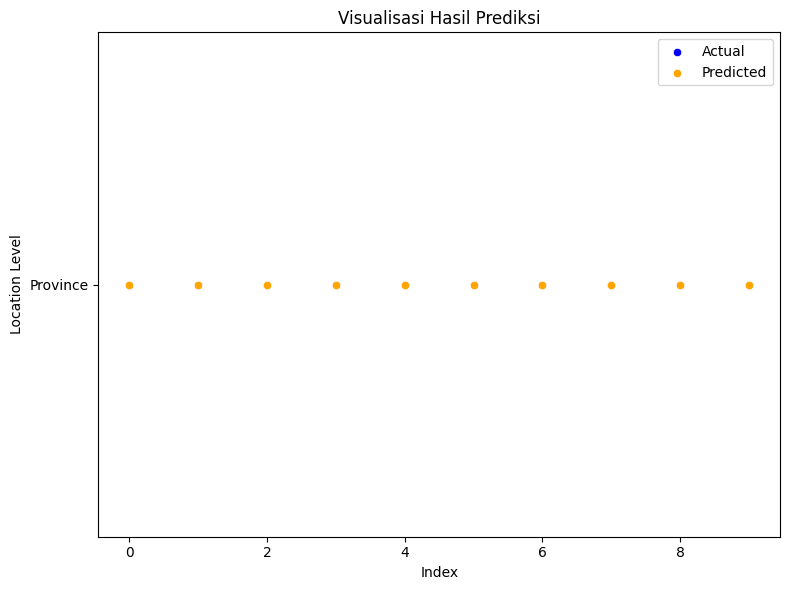

Model disimpan ke: gradient_boosting_model.pkl

Model ini telah dievaluasi dengan visualisasi yang tersedia:
- Matriks Kebingungan: confusion_matrix_gb.png
- Kurva ROC: roc_curve_gb.png
- Pentingnya Fitur: feature_importances_gb.png
- Prediksi Sampel: sample_predictions_gb.png


In [22]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
from tabulate import tabulate

# =======================
# Tahap 1: Memuat Dataset
# =======================
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Menampilkan sekilas data
print("\nSekilas dataset:")
print(tabulate(data.head(), headers="keys", tablefmt="grid"))

# ==============================
# Tahap 2: Eksplorasi Data Awal
# ==============================
print("\nInformasi Dataset:")
print(data.info())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(tabulate(data.describe(), headers="keys", tablefmt="grid"))

# Cek nilai kosong
missing_values = data.isnull().sum()
print("\nJumlah Nilai Kosong:")
print(missing_values[missing_values > 0])

# ========================
# Tahap 3: Pemrosesan Data
# ========================
selected_features = [
    'New Cases', 'New Deaths', 'New Recovered', 'Total Cases',
    'Total Deaths', 'Total Recovered', 'Population', 'Population Density'
]
label_column = 'Location Level'
data = data.dropna(subset=selected_features + [label_column])

X = data[selected_features]
y = data[label_column]

# Label encoding untuk target kategorikal
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi data menjadi train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =========================
# Tahap 4: Pembangunan Model
# =========================
# Menggunakan Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

# ==========================
# Tahap 5: Evaluasi Model
# ==========================
y_pred = gb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('confusion_matrix_gb.png')
plt.show()

# Classification report
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ==========================
# Tahap 6: Visualisasi ROC
# ==========================
y_prob = gb_model.predict_proba(X_test)
n_classes = len(label_encoder.classes_)
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.savefig('roc_curve_gb.png')
plt.show()

# ============================
# Tahap 7: Analisis Fitur
# ============================
feature_importances = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importances")
plt.tight_layout()
plt.savefig('feature_importances_gb.png')
plt.show()

print("\nPentingnya Fitur:")
print(tabulate(feature_importances, headers="keys", tablefmt="grid"))

# ============================
# Tahap 8: Output Prediksi
# ============================
sample_predictions = pd.DataFrame({
    'Index': data.index[:10],
    'Actual': label_encoder.inverse_transform(y_test[:10]),
    'Predicted': label_encoder.inverse_transform(y_pred[:10])
})
print("\nPrediksi pada Sampel:")
print(tabulate(sample_predictions, headers="keys", tablefmt="grid"))

# Visualisasi hasil prediksi sampel
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Actual'],
    label='Actual',
    color='blue'
)
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Predicted'],
    label='Predicted',
    color='orange'
)
plt.title("Visualisasi Hasil Prediksi")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Location Level")
plt.tight_layout()
plt.savefig('sample_predictions_gb.png')
plt.show()

# ============================
# Tahap 9: Menyimpan Model
# ============================
model_path = 'gradient_boosting_model.pkl'
joblib.dump(gb_model, model_path)
print(f"Model disimpan ke: {model_path}")

# ============================
# Tahap 10: Interpretasi Lanjutan
# ============================
print("\nModel ini telah dievaluasi dengan visualisasi yang tersedia:")
print("- Matriks Kebingungan: confusion_matrix_gb.png")
print("- Kurva ROC: roc_curve_gb.png")
print("- Pentingnya Fitur: feature_importances_gb.png")
print("- Prediksi Sampel: sample_predictions_gb.png")


# Supervised learning (RandomForestClassifier) Full code


Sekilas dataset:
+----+----------+---------------------+-------------+-------------+--------------+-----------------+--------------------+---------------+----------------+-------------------+----------------------+------------------+-------------------+-------------+-----------+-------------+----------+-------------+------------------------+-------------------+----------------+-------------------+------------------------+------------------------+--------------+--------------+----------------------+-------------+------------+-------------------------+---------------------------+--------------------------+----------------------------+----------------------+-----------------------+------------------------------+-------------------------------+
|    | Date     | Location ISO Code   | Location    |   New Cases |   New Deaths |   New Recovered |   New Active Cases |   Total Cases |   Total Deaths |   Total Recovered |   Total Active Cases | Location Level   |   City or Regency | Province   

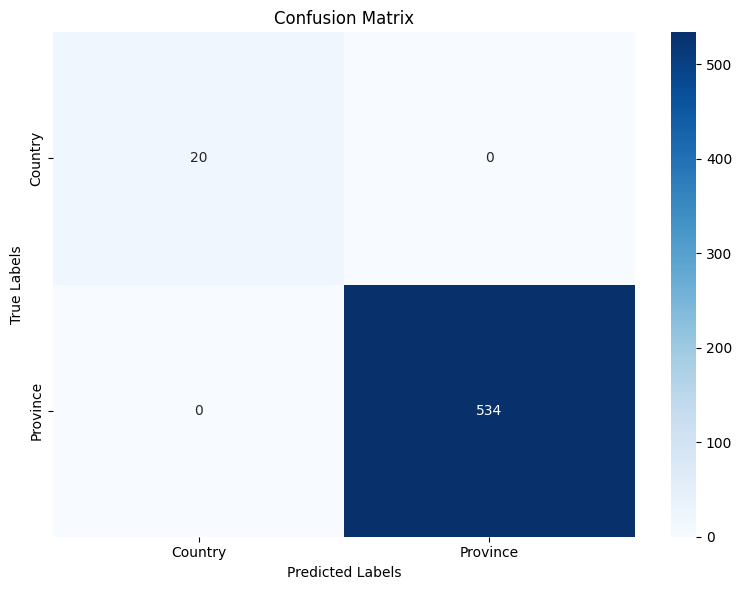


Laporan Klasifikasi:
              precision    recall  f1-score   support

     Country       1.00      1.00      1.00        20
    Province       1.00      1.00      1.00       534

    accuracy                           1.00       554
   macro avg       1.00      1.00      1.00       554
weighted avg       1.00      1.00      1.00       554



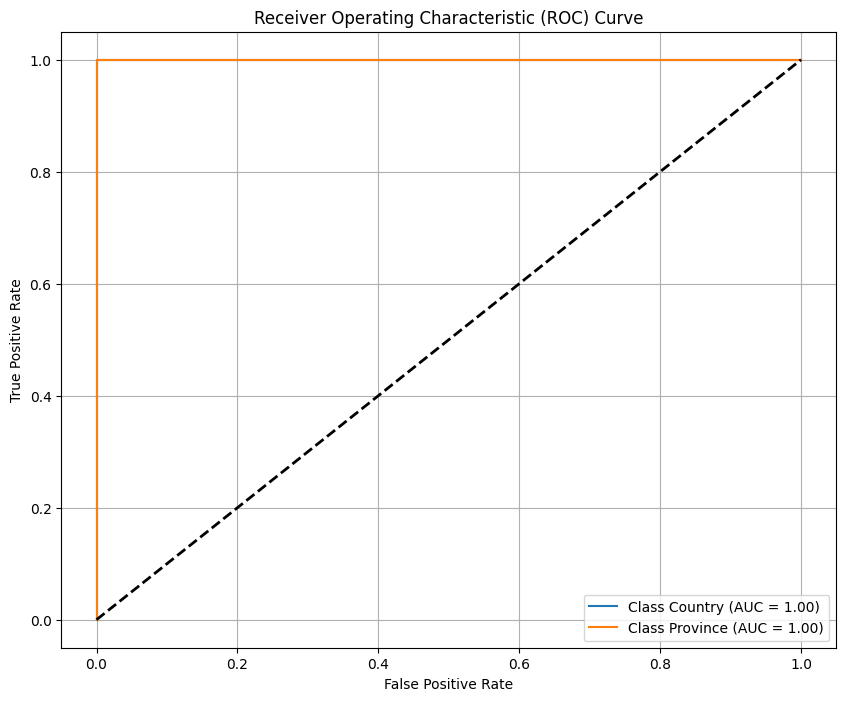

<ipython-input-21-5ffb6c0609a2>:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


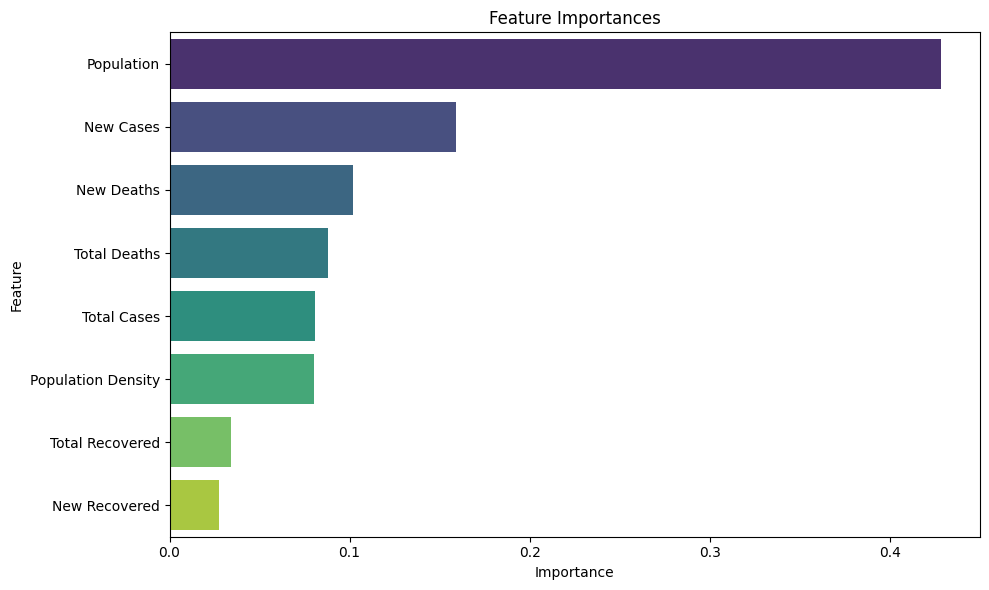


Pentingnya Fitur:
+----+--------------------+--------------+
|    | Feature            |   Importance |
+====+====================+==============+
|  6 | Population         |    0.428646  |
+----+--------------------+--------------+
|  0 | New Cases          |    0.158863  |
+----+--------------------+--------------+
|  1 | New Deaths         |    0.102023  |
+----+--------------------+--------------+
|  4 | Total Deaths       |    0.0879575 |
+----+--------------------+--------------+
|  3 | Total Cases        |    0.0806404 |
+----+--------------------+--------------+
|  7 | Population Density |    0.0799904 |
+----+--------------------+--------------+
|  5 | Total Recovered    |    0.0343653 |
+----+--------------------+--------------+
|  2 | New Recovered      |    0.0275133 |
+----+--------------------+--------------+

Prediksi pada Sampel:
+----+---------+----------+-------------+
|    |   Index | Actual   | Predicted   |
+====+=========+==========+=============+
|  0 |       0 

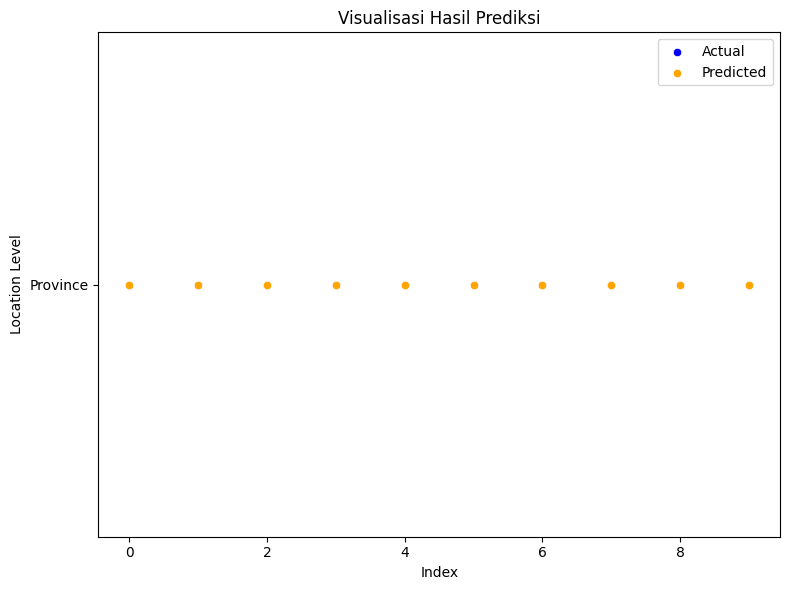

Model disimpan ke: random_forest_model.pkl

Model ini telah dievaluasi dengan visualisasi yang tersedia:
- Matriks Kebingungan: confusion_matrix.png
- Kurva ROC: roc_curve.png
- Pentingnya Fitur: feature_importances.png
- Prediksi Sampel: sample_predictions.png


In [21]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
from tabulate import tabulate

# =======================
# Tahap 1: Memuat Dataset
# =======================
data_path = 'covid_19_indonesia_time_series_all.csv'
data = pd.read_csv(data_path)

# Menampilkan sekilas data
print("\nSekilas dataset:")
print(tabulate(data.head(), headers="keys", tablefmt="grid"))

# ==============================
# Tahap 2: Eksplorasi Data Awal
# ==============================
print("\nInformasi Dataset:")
print(data.info())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(tabulate(data.describe(), headers="keys", tablefmt="grid"))

# Cek nilai kosong
missing_values = data.isnull().sum()
print("\nJumlah Nilai Kosong:")
print(missing_values[missing_values > 0])

# ========================
# Tahap 3: Pemrosesan Data
# ========================
selected_features = [
    'New Cases', 'New Deaths', 'New Recovered', 'Total Cases',
    'Total Deaths', 'Total Recovered', 'Population', 'Population Density'
]
label_column = 'Location Level'
data = data.dropna(subset=selected_features + [label_column])

X = data[selected_features]
y = data[label_column]

# Label encoding untuk target kategorikal
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi data menjadi train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =========================
# Tahap 4: Pembangunan Model
# =========================
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# ==========================
# Tahap 5: Evaluasi Model
# ==========================
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Classification report
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ==========================
# Tahap 6: Visualisasi ROC
# ==========================
y_prob = rf_model.predict_proba(X_test)
n_classes = len(label_encoder.classes_)
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.savefig('roc_curve.png')
plt.show()

# ============================
# Tahap 7: Analisis Fitur
# ============================
feature_importances = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importances")
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()

print("\nPentingnya Fitur:")
print(tabulate(feature_importances, headers="keys", tablefmt="grid"))

# ============================
# Tahap 8: Output Prediksi
# ============================
sample_predictions = pd.DataFrame({
    'Index': data.index[:10],
    'Actual': label_encoder.inverse_transform(y_test[:10]),
    'Predicted': label_encoder.inverse_transform(y_pred[:10])
})
print("\nPrediksi pada Sampel:")
print(tabulate(sample_predictions, headers="keys", tablefmt="grid"))

# Visualisasi hasil prediksi sampel
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Actual'],
    label='Actual',
    color='blue'
)
sns.scatterplot(
    x=range(len(sample_predictions)),
    y=sample_predictions['Predicted'],
    label='Predicted',
    color='orange'
)
plt.title("Visualisasi Hasil Prediksi")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Location Level")
plt.tight_layout()
plt.savefig('sample_predictions.png')
plt.show()

# ============================
# Tahap 9: Menyimpan Model
# ============================
model_path = 'random_forest_model.pkl'
joblib.dump(rf_model, model_path)
print(f"Model disimpan ke: {model_path}")

# ============================
# Tahap 10: Interpretasi Lanjutan
# ============================
print("\nModel ini telah dievaluasi dengan visualisasi yang tersedia:")
print("- Matriks Kebingungan: confusion_matrix.png")
print("- Kurva ROC: roc_curve.png")
print("- Pentingnya Fitur: feature_importances.png")
print("- Prediksi Sampel: sample_predictions.png")
